In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Classification models and metrics (added for multiclass classifier)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load foods_health_scores_allergens.csv for the Nutri-Score prediction task
df_health = pd.read_csv('foods_health_scores_allergens.csv')
df_health.head()

,product_name,brands,categories,ingredients,nutriscore_grade,nova_group,ecoscore_grade,allergens,energy_kcal,fat_100g,...,proteins_100g,salt_100g,sodium_100g,contains_gluten,contains_dairy,contains_nuts,contains_soy,contains_eggs,contains_fish,food_type
0,Sidi Ali,سيدي علي,"en:beverages-and-beverages-preparations, en:be...",OBD1 999 999 1112606 266963207 mb,A,NaN,NOT-APPLICABLE,NaN,0.0,0.0,...,0.0,0.000000,0.000000,False,False,False,False,False,False,Branded/Packaged
1,Perly,Perly,"en:dairies, en:fermented-foods, en:fermented-m...","milk cream, cream, sugar, banana, bacteria",UNKNOWN,3.0,B,"en:banana, en:milk",97.0,3.0,...,8.0,NaN,NaN,False,True,False,False,False,False,Branded/Packaged
2,Sidi Ali,Sidi Ali,"en:beverages-and-beverages-preparations, en:be...","Sodium, Calcium, Magnésium, Potassium, Bicarbo...",A,1.0,NOT-APPLICABLE,NaN,NaN,NaN,...,NaN,0.065000,0.026000,False,False,False,False,False,False,Branded/Packaged
3,Eau minérale naturelle,sidi ali,"en:beverages-and-beverages-preparations, en:be...",100% mineral water,A,1.0,NOT-APPLICABLE,NaN,NaN,NaN,...,NaN,0.065000,0.026000,False,False,False,False,False,False,Branded/Packaged
4,اكوافينا,AQUAFINA,"en:beverages-and-beverages-preparations, en:be...",ouverture et avant le : Voir bouteille. après ...,A,NaN,NOT-APPLICABLE,NaN,0.0,0.0,...,0.0,0.000508,0.000203,False,False,False,False,False,False,Branded/Packaged


In [3]:
print(f"Number of rows: {df_health.shape[0]}, Number of columns: {df_health.shape[1]}")
df_health.info()

Number of rows: 4997, Number of columns: 24
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4997 entries, 0 to 4996
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_name        4785 non-null   object 
 1   brands              4751 non-null   object 
 2   categories          4913 non-null   object 
 3   ingredients         4797 non-null   object 
 4   nutriscore_grade    4983 non-null   object 
 5   nova_group          4522 non-null   float64
 6   ecoscore_grade      4984 non-null   object 
 7   allergens           3332 non-null   object 
 8   energy_kcal         4682 non-null   float64
 9   fat_100g            4695 non-null   float64
 10  saturated_fat_100g  4617 non-null   float64
 11  carbs_100g          4676 non-null   float64
 12  sugars_100g         4631 non-null   float64
 13  fiber_100g          3495 non-null   float64
 14  proteins_100g       4690 non-null   float64
 15  salt_100g  

In [4]:
missing_values = df_health.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
display(missing_values)

# --- Recommended Missing Value Handling ---

# 1. Handle 'nutriscore_grade' and 'ecoscore_grade': Drop rows if they are target/critical features.
#    Nutri-Score is often the target in such datasets, so dropping is preferred to avoid target leakage.
df_health.dropna(subset=['nutriscore_grade', 'ecoscore_grade'], inplace=True)
print(f"\nDropped rows with missing 'nutriscore_grade' or 'ecoscore_grade'. Remaining rows: {len(df_health)}")

# 2. Impute numerical columns with the median
numerical_cols = [
    'nova_group', 'energy_kcal', 'fat_100g', 'saturated_fat_100g',
    'carbs_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g',
    'salt_100g', 'sodium_100g'
]
for col in numerical_cols:
    if col in df_health.columns:
        # Calculate median only for non-NaN values to avoid errors if a column is entirely NaN after previous operations
        median_val = df_health[col].median()
        df_health[col].fillna(median_val, inplace=True)
        print(f"Imputed '{col}' with median: {median_val}")

# 3. Impute categorical/textual columns
#    'allergens': Fill with 'no_allergens' as NaN often implies absence here.
if 'allergens' in df_health.columns:
    df_health['allergens'].fillna('no_allergens', inplace=True)
    print(f"Imputed 'allergens' with 'no_allergens'.")

#    Other categorical: Fill with 'Unknown'
categorical_other_cols = [
    'brands', 'product_name', 'ingredients', 'categories'
]
for col in categorical_other_cols:
    if col in df_health.columns:
        df_health[col].fillna('Unknown', inplace=True)
        print(f"Imputed '{col}' with 'Unknown'.")

print("\nMissing values after handling:")
display(df_health.isnull().sum()[df_health.isnull().sum() > 0].sort_values(ascending=False))

,0
allergens,1665
fiber_100g,1502
nova_group,475
saturated_fat_100g,380
sugars_100g,366
sodium_100g,344
salt_100g,344
carbs_100g,321
energy_kcal,315
proteins_100g,307



Dropped rows with missing 'nutriscore_grade' or 'ecoscore_grade'. Remaining rows: 4983
Imputed 'nova_group' with median: 4.0
Imputed 'energy_kcal' with median: 295.0
Imputed 'fat_100g' with median: 7.42
Imputed 'saturated_fat_100g' with median: 1.5
Imputed 'carbs_100g' with median: 19.6999996185305
Imputed 'sugars_100g' with median: 4.3
Imputed 'fiber_100g' with median: 3.0
Imputed 'proteins_100g' with median: 6.3
Imputed 'salt_100g' with median: 0.312
Imputed 'sodium_100g' with median: 0.125
Imputed 'allergens' with 'no_allergens'.
Imputed 'brands' with 'Unknown'.
Imputed 'product_name' with 'Unknown'.
Imputed 'ingredients' with 'Unknown'.
Imputed 'categories' with 'Unknown'.

Missing values after handling:


,0


In [5]:
# Check descriptive statistics
print("Descriptive statistics after missing value handling:")
display(df_health.describe())

Descriptive statistics after missing value handling:


,nova_group,energy_kcal,fat_100g,saturated_fat_100g,carbs_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
count,4983.000000,4983.000000,4983.000000,4983.000000,4983.000000,4983.000000,4.983000e+03,4983.000000,4983.000000,4983.000000
mean,3.345575,300.849354,15.501340,5.196549,31.803627,11.798937,1.226418e+09,7.286626,1.400069,0.560041
std,1.006494,214.865769,21.423919,12.030166,129.752559,21.328729,8.657331e+10,10.806086,14.281422,5.712562
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,3.000000,105.800000,1.600000,0.312000,5.000000,1.300000,1.480000e+00,2.200000,0.048700,0.019480
50%,4.000000,295.000000,7.420000,1.500000,19.700000,4.300000,3.000000e+00,6.300000,0.312000,0.125000
75%,4.000000,448.980000,22.000000,6.200000,57.000000,14.000000,4.800000e+00,9.400000,0.950000,0.380000
max,4.000000,5280.000000,554.000000,595.000000,8989.000000,895.000000,6.111242e+12,597.000000,898.000000,359.200000


In [6]:
# Identify categorical columns that are still objects after missing value handling
categorical_cols = df_health.select_dtypes(include='object').columns.tolist()
print("Categorical columns identified for encoding/processing:", categorical_cols)

# 1. Ordinal Encoding for 'nutriscore_grade' (target variable)
nutriscore_mapping = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'UNKNOWN': -1}
if 'nutriscore_grade' in df_health.columns:
    df_health['nutriscore_grade_encoded'] = df_health['nutriscore_grade'].map(nutriscore_mapping)
    # Fill any remaining NaNs (due to unmapped categories) with -1
    df_health['nutriscore_grade_encoded'].fillna(-1, inplace=True)
    print("Mapped 'nutriscore_grade' to numerical values and handled unmapped categories.")
else:
    print("'nutriscore_grade' column not found, skipping ordinal encoding.")

# 2. Ordinal Encoding for 'ecoscore_grade'
ecoscore_mapping = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'NOT-APPLICABLE': -1, 'UNKNOWN': -1}
if 'ecoscore_grade' in df_health.columns:
    df_health['ecoscore_grade_encoded'] = df_health['ecoscore_grade'].map(ecoscore_mapping)
    # Fill any remaining NaNs (due to unmapped categories) with -1
    df_health['ecoscore_grade_encoded'].fillna(-1, inplace=True)
    print("Mapped 'ecoscore_grade' to numerical values and handled unmapped categories.")
else:
    print("'ecoscore_grade' column not found, skipping ordinal encoding.")

# 3. One-Hot Encode 'food_type'
# Check if 'food_type' column exists before encoding
if 'food_type' in df_health.columns:
    df_health = pd.get_dummies(df_health, columns=['food_type'], prefix='food_type')
    print("One-Hot encoded 'food_type'.")
else:
    print("'food_type' column not found, skipping one-hot encoding.")

# 4. Simplify 'allergens' to a binary 'has_allergens' feature
# Check if 'allergens' column exists before processing
if 'allergens' in df_health.columns:
    df_health['has_allergens'] = df_health['allergens'].apply(lambda x: 0 if x == 'no_allergens' else 1)
    print("Created 'has_allergens' feature from 'allergens'.")
else:
    print("'allergens' column not found, skipping 'has_allergens' creation.")

# 5. Drop original categorical columns and high-cardinality text columns
columns_to_drop = [
    'product_name', 'brands', 'categories', 'ingredients', # High cardinality text columns
    'allergens', # Original allergens column
    'nutriscore_grade', 'ecoscore_grade' # Original grade columns after encoding
]

# Filter to ensure only existing columns are dropped
columns_to_drop_existing = [col for col in columns_to_drop if col in df_health.columns]
df_health.drop(columns=columns_to_drop_existing, inplace=True)
print(f"Dropped original categorical and high cardinality columns: {columns_to_drop_existing}")

print("\nDataFrame head after categorical encoding and dropping columns:")
display(df_health.head())

print("\nDataFrame info after categorical encoding and dropping columns:")
df_health.info()


Categorical columns identified for encoding/processing: ['product_name', 'brands', 'categories', 'ingredients', 'nutriscore_grade', 'ecoscore_grade', 'allergens', 'food_type']
Mapped 'nutriscore_grade' to numerical values and handled unmapped categories.
Mapped 'ecoscore_grade' to numerical values and handled unmapped categories.
One-Hot encoded 'food_type'.
Created 'has_allergens' feature from 'allergens'.
Dropped original categorical and high cardinality columns: ['product_name', 'brands', 'categories', 'ingredients', 'allergens', 'nutriscore_grade', 'ecoscore_grade']

DataFrame head after categorical encoding and dropping columns:


,nova_group,energy_kcal,fat_100g,saturated_fat_100g,carbs_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,contains_gluten,contains_dairy,contains_nuts,contains_soy,contains_eggs,contains_fish,nutriscore_grade_encoded,ecoscore_grade_encoded,food_type_Branded/Packaged,has_allergens
0,4.0,0.0,0.00,0.0,4.2,1.4,0.0,0.0,0.000000,0.000000,False,False,False,False,False,False,0.0,-1.0,True,0
1,3.0,97.0,3.00,1.5,9.4,4.3,3.0,8.0,0.312000,0.125000,False,True,False,False,False,False,-1.0,1.0,True,1
2,1.0,295.0,7.42,1.5,19.7,4.3,3.0,6.3,0.065000,0.026000,False,False,False,False,False,False,0.0,-1.0,True,0
3,1.0,295.0,7.42,1.5,19.7,4.3,3.0,6.3,0.065000,0.026000,False,False,False,False,False,False,0.0,-1.0,True,0
4,4.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.000508,0.000203,False,False,False,False,False,False,0.0,-1.0,True,0



DataFrame info after categorical encoding and dropping columns:
<class 'pandas.core.frame.DataFrame'>
Index: 4983 entries, 0 to 4996
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   nova_group                  4983 non-null   float64
 1   energy_kcal                 4983 non-null   float64
 2   fat_100g                    4983 non-null   float64
 3   saturated_fat_100g          4983 non-null   float64
 4   carbs_100g                  4983 non-null   float64
 5   sugars_100g                 4983 non-null   float64
 6   fiber_100g                  4983 non-null   float64
 7   proteins_100g               4983 non-null   float64
 8   salt_100g                   4983 non-null   float64
 9   sodium_100g                 4983 non-null   float64
 10  contains_gluten             4983 non-null   bool   
 11  contains_dairy              4983 non-null   bool   
 12  contains_nuts               49

Descriptive statistics before outlier capping:


,nova_group,energy_kcal,fat_100g,saturated_fat_100g,carbs_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
count,4983.000000,4983.000000,4983.000000,4983.000000,4983.000000,4983.000000,4.983000e+03,4983.000000,4983.000000,4983.000000
mean,3.345575,300.849354,15.501340,5.196549,31.803627,11.798937,1.226418e+09,7.286626,1.400069,0.560041
std,1.006494,214.865769,21.423919,12.030166,129.752559,21.328729,8.657331e+10,10.806086,14.281422,5.712562
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,3.000000,105.800000,1.600000,0.312000,5.000000,1.300000,1.480000e+00,2.200000,0.048700,0.019480
50%,4.000000,295.000000,7.420000,1.500000,19.700000,4.300000,3.000000e+00,6.300000,0.312000,0.125000
75%,4.000000,448.980000,22.000000,6.200000,57.000000,14.000000,4.800000e+00,9.400000,0.950000,0.380000
max,4.000000,5280.000000,554.000000,595.000000,8989.000000,895.000000,6.111242e+12,597.000000,898.000000,359.200000


Capped outliers for column: nova_group


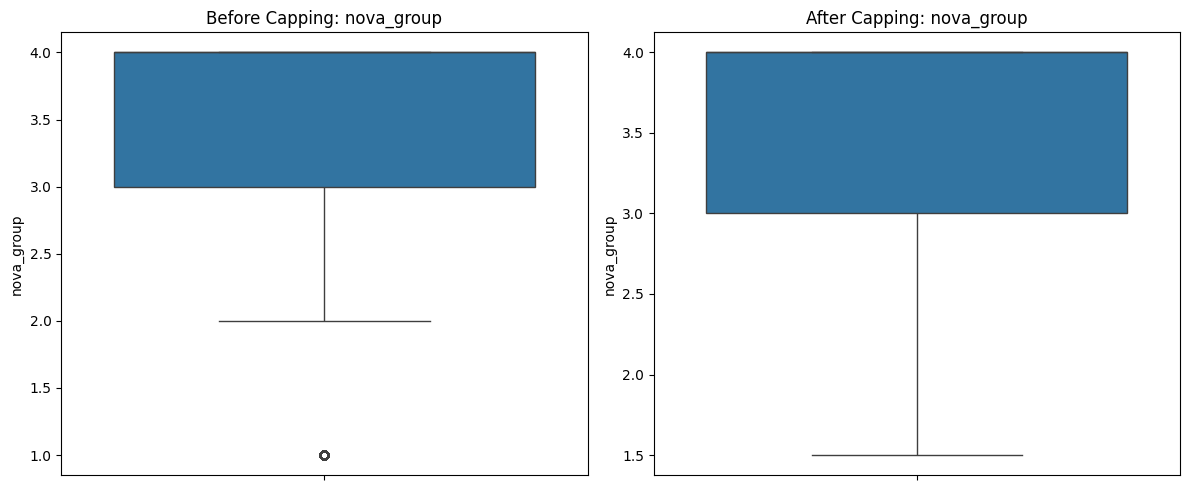

Capped outliers for column: energy_kcal


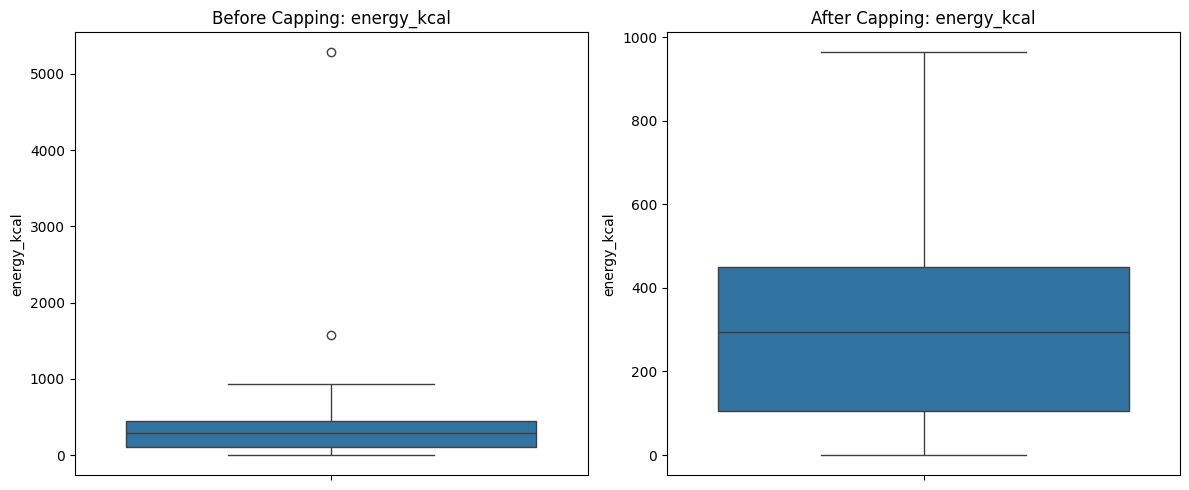

Capped outliers for column: fat_100g


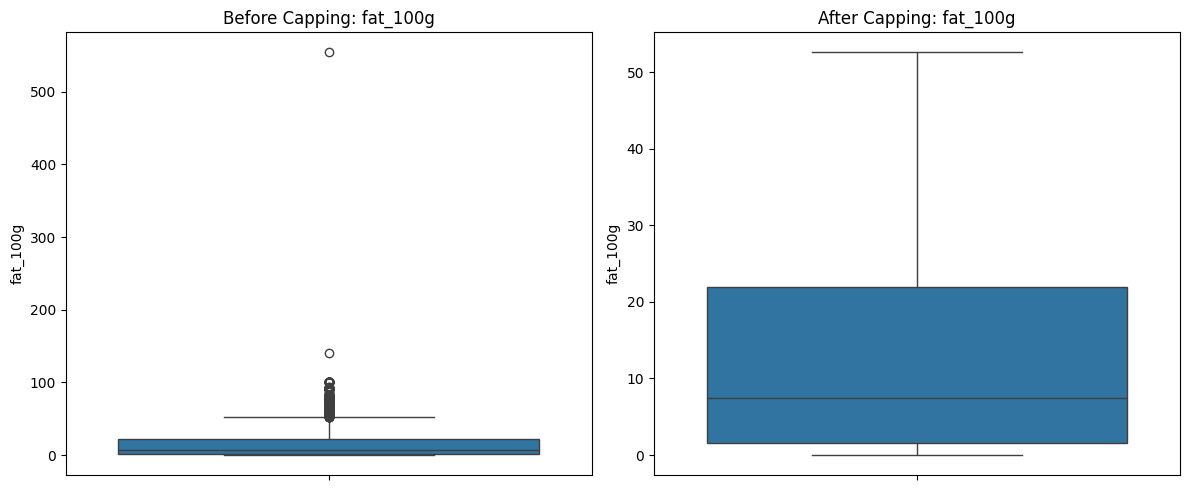

Capped outliers for column: saturated_fat_100g


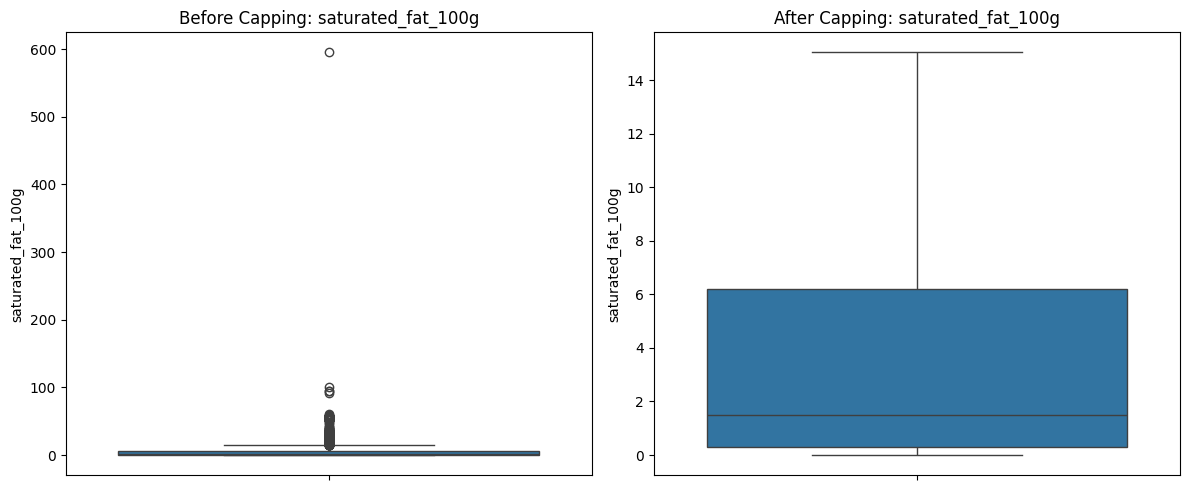

Capped outliers for column: carbs_100g


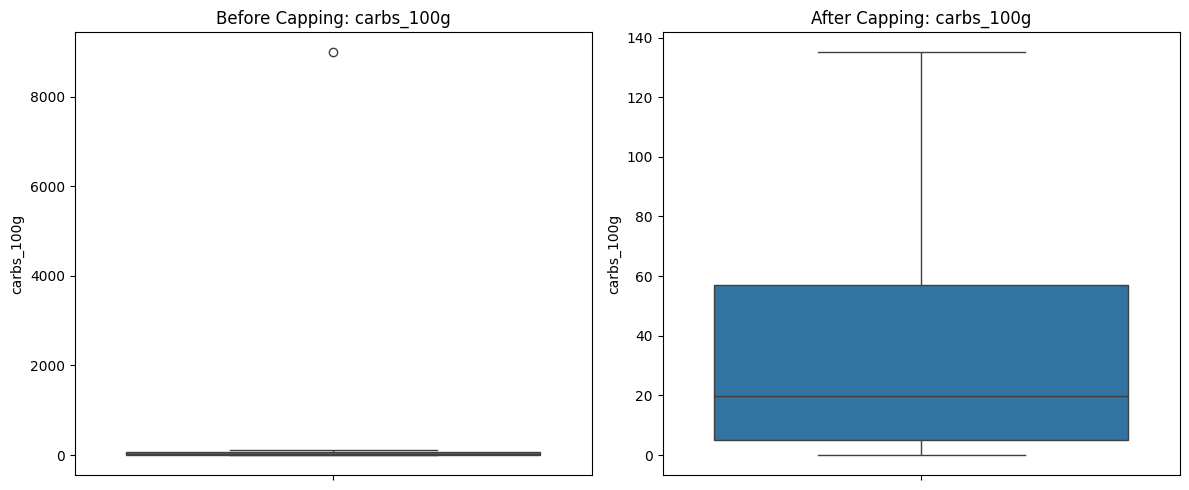

Capped outliers for column: sugars_100g


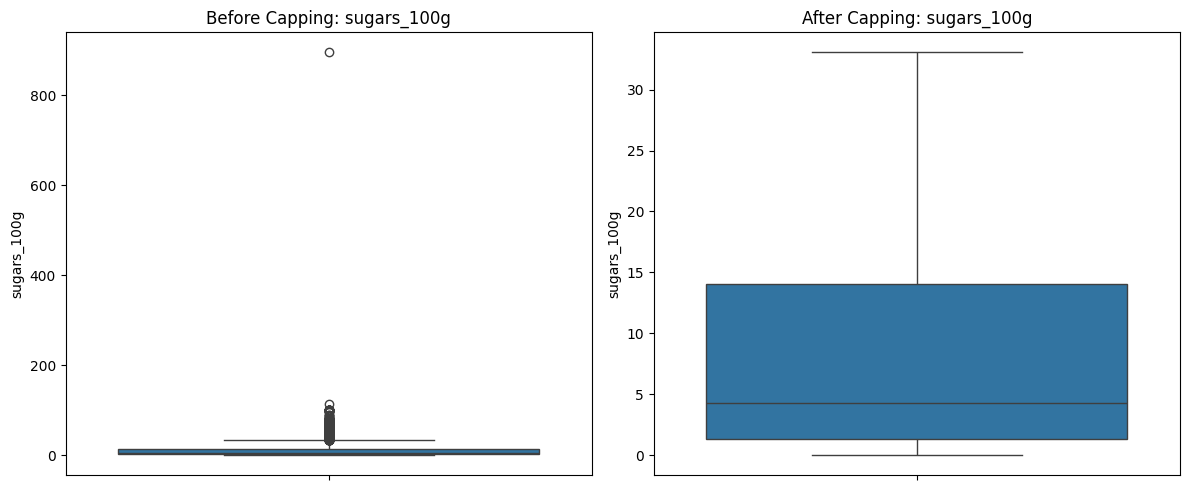

Capped outliers for column: fiber_100g


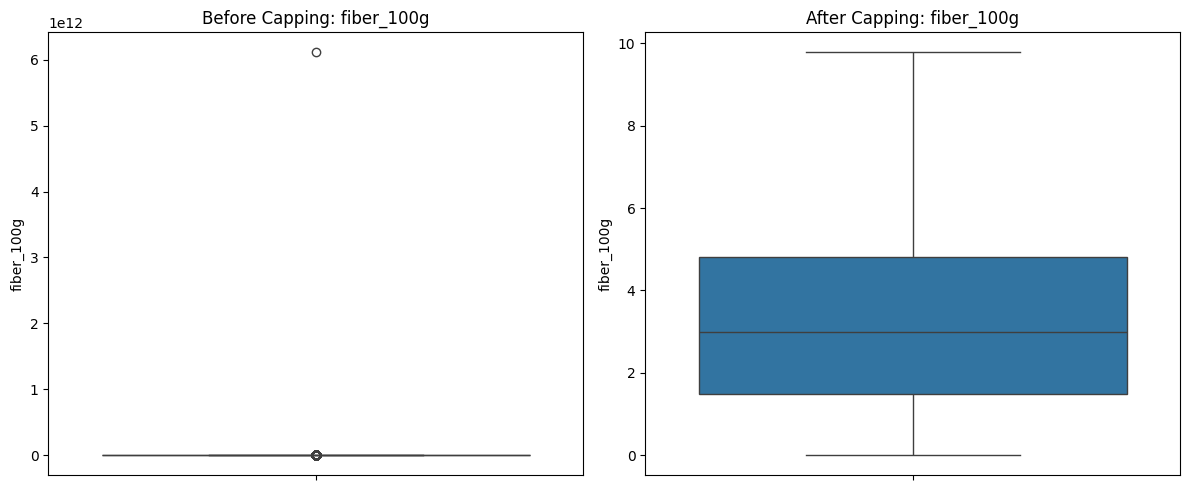

Capped outliers for column: proteins_100g


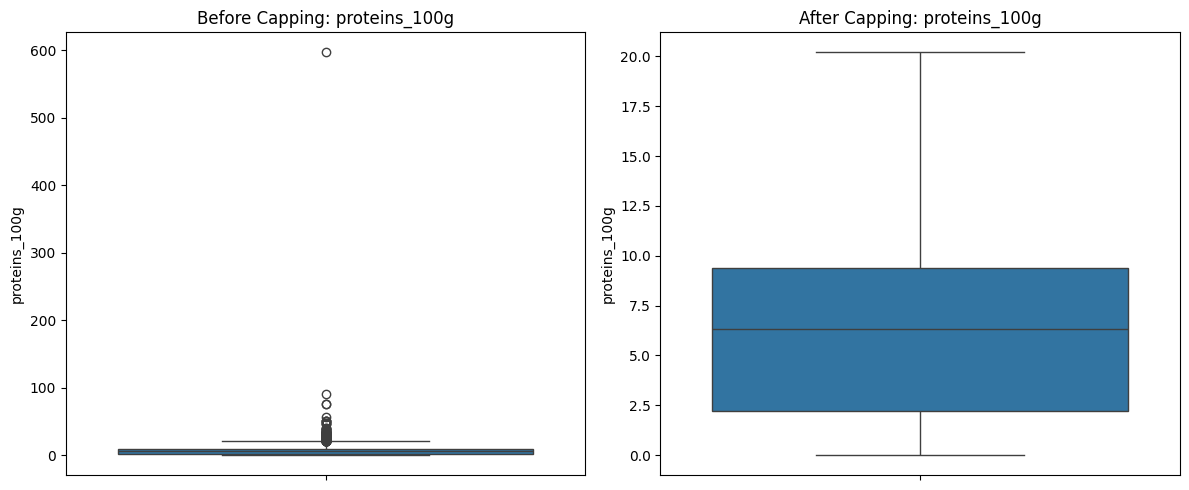

Capped outliers for column: salt_100g


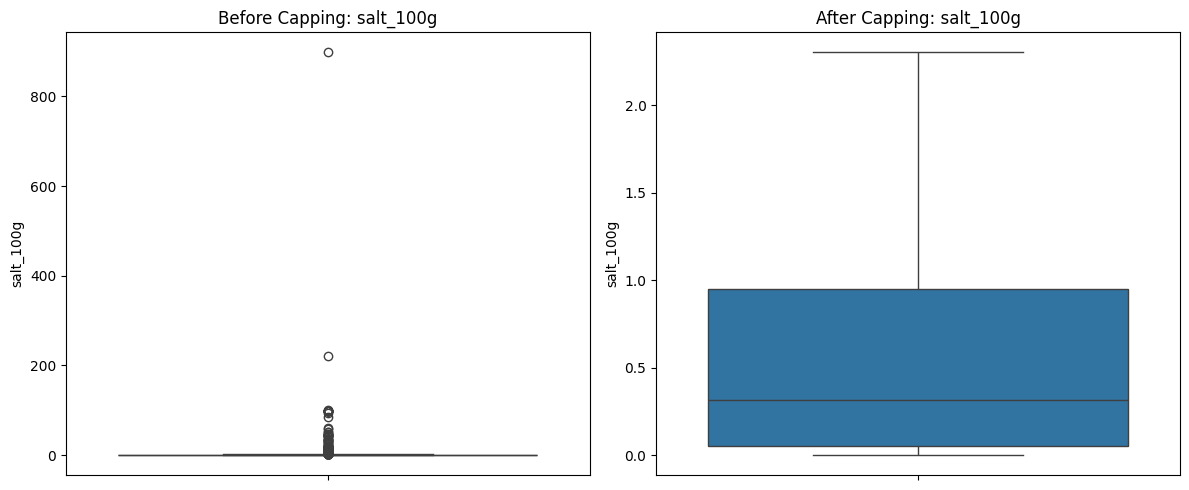

Capped outliers for column: sodium_100g


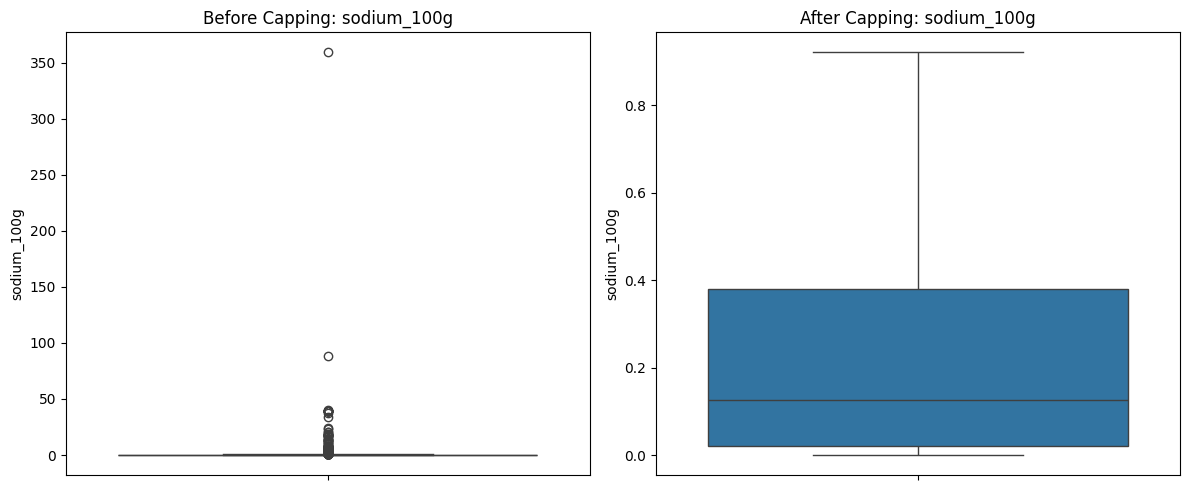


Descriptive statistics after outlier capping:


,nova_group,energy_kcal,fat_100g,saturated_fat_100g,carbs_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
count,4983.000000,4983.000000,4983.000000,4983.000000,4983.000000,4983.000000,4983.000000,4983.000000,4983.000000,4983.000000
mean,3.404174,299.859488,14.024915,4.039258,30.026786,9.371965,3.535685,6.764778,0.582590,0.233048
std,0.874042,202.578376,15.824818,5.120832,27.026981,11.044896,2.845016,5.465275,0.656224,0.262481
min,1.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,105.800000,1.600000,0.312000,5.000000,1.300000,1.480000,2.200000,0.048700,0.019480
50%,4.000000,295.000000,7.420000,1.500000,19.700000,4.300000,3.000000,6.300000,0.312000,0.125000
75%,4.000000,448.980000,22.000000,6.200000,57.000000,14.000000,4.800000,9.400000,0.950000,0.380000
max,4.000000,963.750000,52.600000,15.032000,135.000000,33.050000,9.780000,20.200000,2.301950,0.920780


In [7]:
print("Descriptive statistics before outlier capping:")
display(df_health[numerical_cols].describe())

# Using IQR method for outlier capping
for col in numerical_cols:
    if col in df_health.columns:
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        sns.boxplot(y=df_health[col])
        plt.title(f'Before Capping: {col}')
        plt.ylabel(col)

        Q1 = df_health[col].quantile(0.25)
        Q3 = df_health[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Cap outliers
        df_health[col] = np.where(df_health[col] < lower_bound, lower_bound, df_health[col])
        df_health[col] = np.where(df_health[col] > upper_bound, upper_bound, df_health[col])
        print(f"Capped outliers for column: {col}")

        plt.subplot(1, 2, 2)
        sns.boxplot(y=df_health[col])
        plt.title(f'After Capping: {col}')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

print("\nDescriptive statistics after outlier capping:")
display(df_health[numerical_cols].describe())

In [8]:
print("DataFrame head (unscaled numerical features):")
display(df_health.head())

print("\nDescriptive statistics of numerical features (unscaled):")
display(df_health[numerical_cols].describe())

DataFrame head (unscaled numerical features):


,nova_group,energy_kcal,fat_100g,saturated_fat_100g,carbs_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,contains_gluten,contains_dairy,contains_nuts,contains_soy,contains_eggs,contains_fish,nutriscore_grade_encoded,ecoscore_grade_encoded,food_type_Branded/Packaged,has_allergens
0,4.0,0.0,0.00,0.0,4.2,1.4,0.0,0.0,0.000000,0.000000,False,False,False,False,False,False,0.0,-1.0,True,0
1,3.0,97.0,3.00,1.5,9.4,4.3,3.0,8.0,0.312000,0.125000,False,True,False,False,False,False,-1.0,1.0,True,1
2,1.5,295.0,7.42,1.5,19.7,4.3,3.0,6.3,0.065000,0.026000,False,False,False,False,False,False,0.0,-1.0,True,0
3,1.5,295.0,7.42,1.5,19.7,4.3,3.0,6.3,0.065000,0.026000,False,False,False,False,False,False,0.0,-1.0,True,0
4,4.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.000508,0.000203,False,False,False,False,False,False,0.0,-1.0,True,0



Descriptive statistics of numerical features (unscaled):


,nova_group,energy_kcal,fat_100g,saturated_fat_100g,carbs_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
count,4983.000000,4983.000000,4983.000000,4983.000000,4983.000000,4983.000000,4983.000000,4983.000000,4983.000000,4983.000000
mean,3.404174,299.859488,14.024915,4.039258,30.026786,9.371965,3.535685,6.764778,0.582590,0.233048
std,0.874042,202.578376,15.824818,5.120832,27.026981,11.044896,2.845016,5.465275,0.656224,0.262481
min,1.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,105.800000,1.600000,0.312000,5.000000,1.300000,1.480000,2.200000,0.048700,0.019480
50%,4.000000,295.000000,7.420000,1.500000,19.700000,4.300000,3.000000,6.300000,0.312000,0.125000
75%,4.000000,448.980000,22.000000,6.200000,57.000000,14.000000,4.800000,9.400000,0.950000,0.380000
max,4.000000,963.750000,52.600000,15.032000,135.000000,33.050000,9.780000,20.200000,2.301950,0.920780


In [9]:
# 1. Nutrient Ratios
# Handle division by zero by replacing 0 with a small epsilon or NaN, then impute
# Fat-to-Protein Ratio
df_health['fat_to_protein_ratio'] = df_health.apply(lambda row: row['fat_100g'] / row['proteins_100g'] if row['proteins_100g'] != 0 else np.nan, axis=1)

# Sugar-to-Fiber Ratio
df_health['sugar_to_fiber_ratio'] = df_health.apply(lambda row: row['sugars_100g'] / row['fiber_100g'] if row['fiber_100g'] != 0 else np.nan, axis=1)

# Sodium-to-Energy Ratio
df_health['sodium_to_energy_ratio'] = df_health.apply(lambda row: row['sodium_100g'] / row['energy_kcal'] if row['energy_kcal'] != 0 else np.nan, axis=1)

# Impute any NaN values created by division by zero, e.g., with 0 or median after creation
# For simplicity, let's fill with 0 for these ratios as they would indicate absence of the denominator ingredient
df_health['fat_to_protein_ratio'].fillna(0, inplace=True)
df_health['sugar_to_fiber_ratio'].fillna(0, inplace=True)
df_health['sodium_to_energy_ratio'].fillna(0, inplace=True)

# 2. Total Allergen Count
allergen_cols = [
    'contains_gluten', 'contains_dairy', 'contains_nuts',
    'contains_soy', 'contains_eggs', 'contains_fish'
]
# Convert boolean columns to integer (True=1, False=0) and sum them
df_health['total_allergens_present'] = df_health[allergen_cols].astype(int).sum(axis=1)

print("New features created and added to df_health:")
display(df_health[['fat_to_protein_ratio', 'sugar_to_fiber_ratio', 'sodium_to_energy_ratio', 'total_allergens_present']].head())

print("\nDataFrame info after feature engineering:")
df_health.info()

New features created and added to df_health:


,fat_to_protein_ratio,sugar_to_fiber_ratio,sodium_to_energy_ratio,total_allergens_present
0,0.000000,0.000000,0.000000,0
1,0.375000,1.433333,0.001289,1
2,1.177778,1.433333,0.000088,0
3,1.177778,1.433333,0.000088,0
4,0.000000,0.000000,0.000000,0



DataFrame info after feature engineering:
<class 'pandas.core.frame.DataFrame'>
Index: 4983 entries, 0 to 4996
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   nova_group                  4983 non-null   float64
 1   energy_kcal                 4983 non-null   float64
 2   fat_100g                    4983 non-null   float64
 3   saturated_fat_100g          4983 non-null   float64
 4   carbs_100g                  4983 non-null   float64
 5   sugars_100g                 4983 non-null   float64
 6   fiber_100g                  4983 non-null   float64
 7   proteins_100g               4983 non-null   float64
 8   salt_100g                   4983 non-null   float64
 9   sodium_100g                 4983 non-null   float64
 10  contains_gluten             4983 non-null   bool   
 11  contains_dairy              4983 non-null   bool   
 12  contains_nuts               4983 non-null   bool   


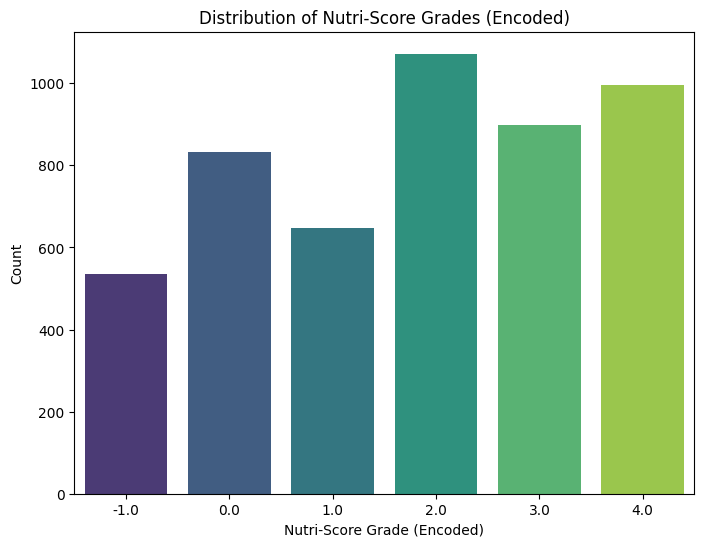

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='nutriscore_grade_encoded', data=df_health, palette='viridis')
plt.title('Distribution of Nutri-Score Grades (Encoded)')
plt.xlabel('Nutri-Score Grade (Encoded)')
plt.ylabel('Count')
plt.show()

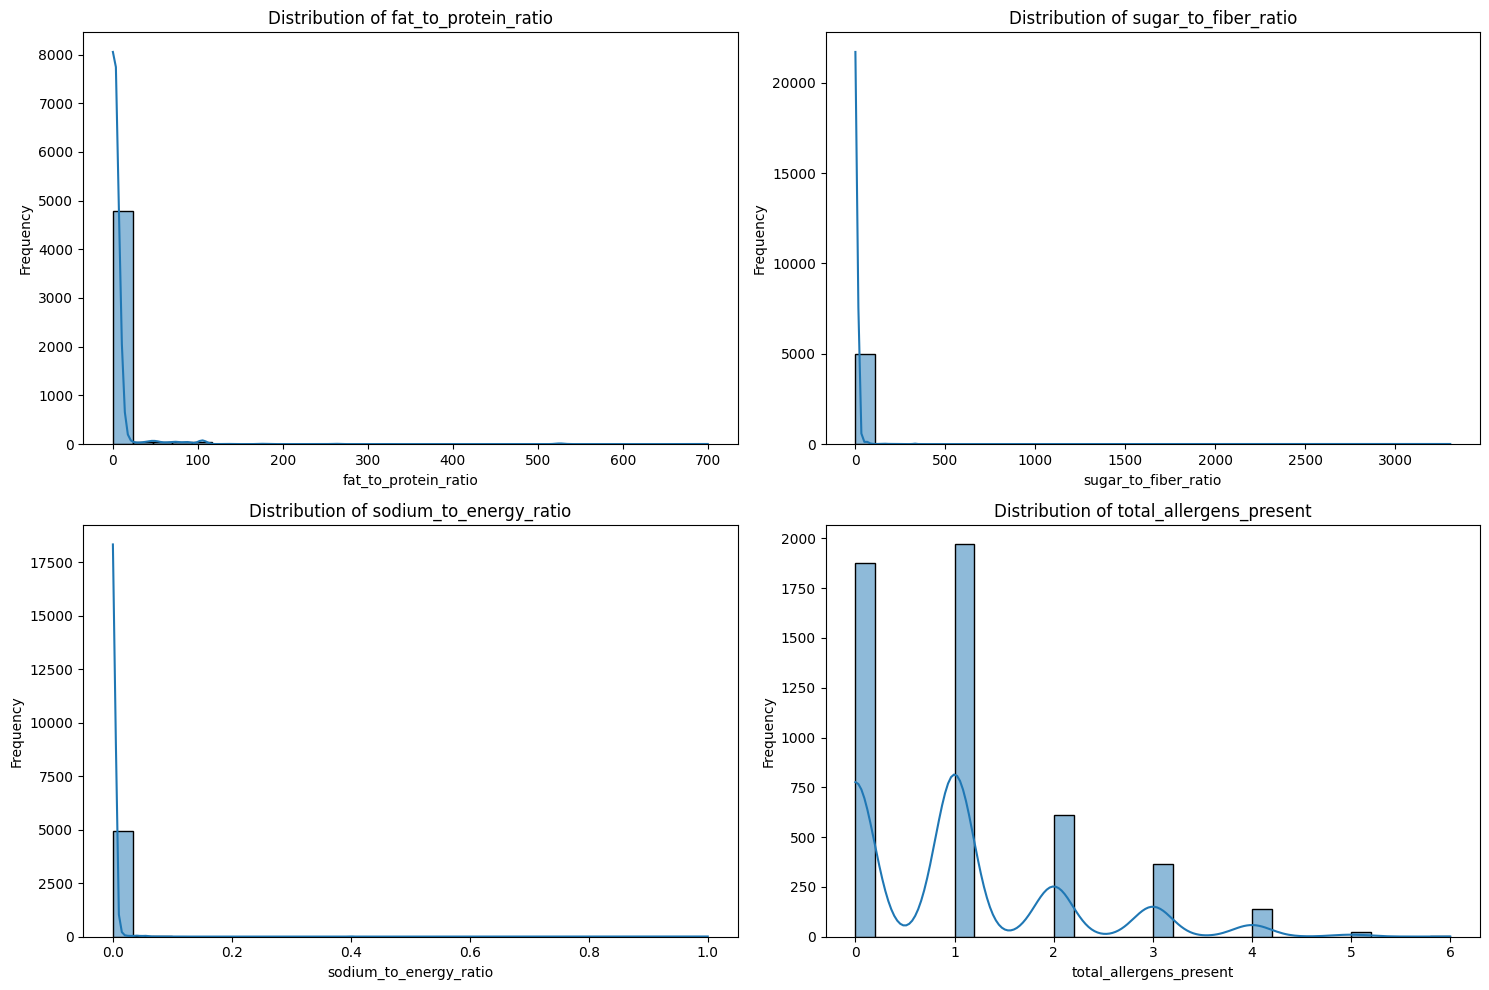

In [11]:
new_numerical_features = [
    'fat_to_protein_ratio', 'sugar_to_fiber_ratio',
    'sodium_to_energy_ratio', 'total_allergens_present'
]

plt.figure(figsize=(15, 10))
for i, col in enumerate(new_numerical_features):
    plt.subplot(2, 2, i + 1) # 2 rows, 2 columns
    sns.histplot(df_health[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

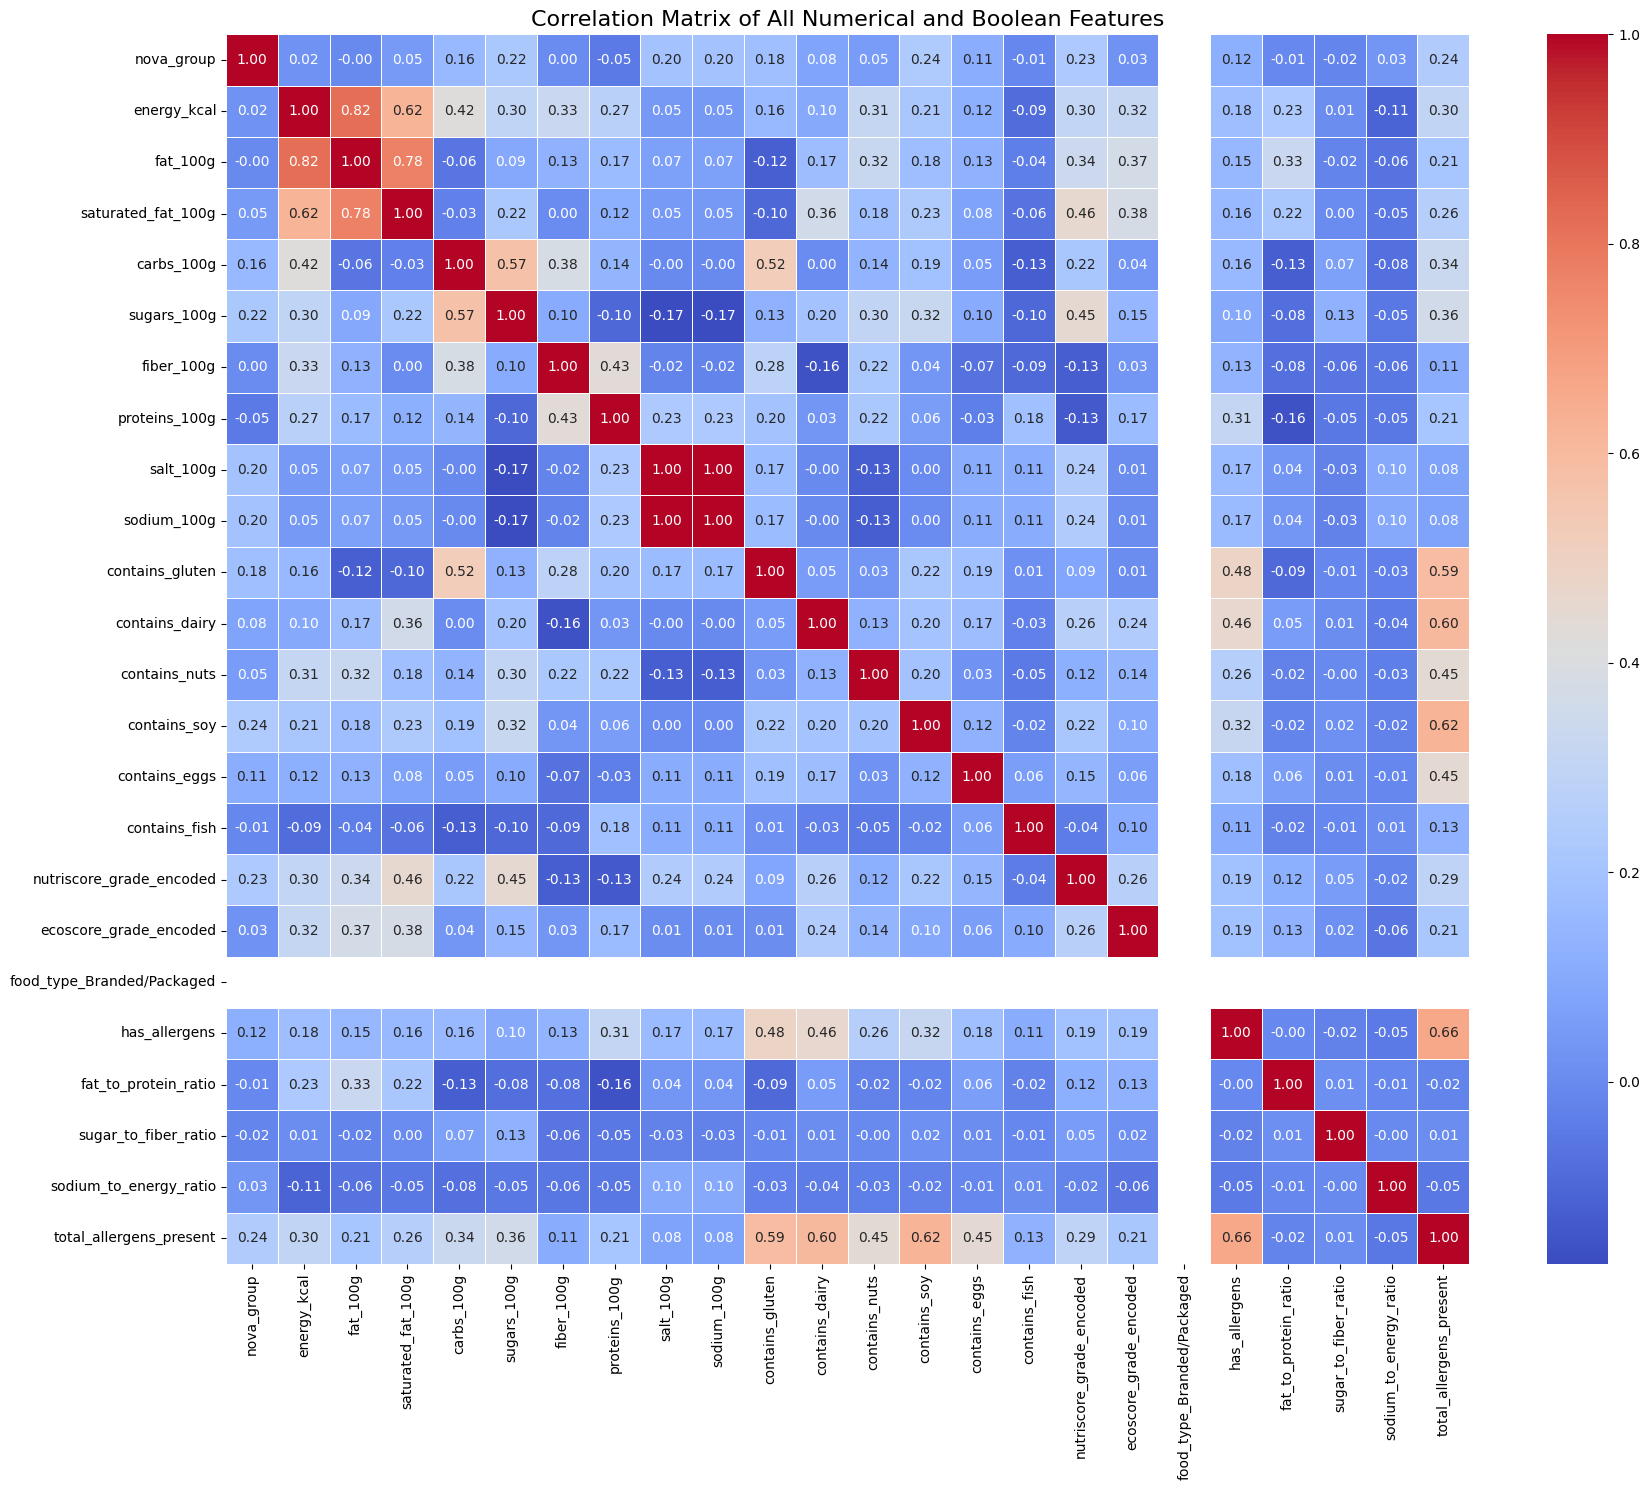

In [12]:
# Select only numerical and boolean columns for correlation matrix
# Boolean columns will be treated as 0s and 1s during correlation calculation
df_for_corr = df_health.select_dtypes(include=[np.number, bool])

plt.figure(figsize=(18, 15))
sns.heatmap(df_for_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Numerical and Boolean Features', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
import numpy as np
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# Drop 'ecoscore_grade_encoded' from features to avoid potential target leakage or multicollinearity
# when predicting Nutri-Score, as they are conceptually similar health scores.
X = df_health.drop(['nutriscore_grade_encoded', 'ecoscore_grade_encoded'], axis=1)
y = df_health['nutriscore_grade_encoded']

# Filter out rows where y is -1 (UNKNOWN/NOT-APPLICABLE Nutri-Score) or NaN values
# This is crucial for stratification and model training consistency.
valid_indices = (y != -1) & (~y.isna())

X = X[valid_indices]
y = y[valid_indices]

# Ensure there are still samples after filtering
if len(y) == 0:
    print("No valid samples left after removing UNKNOWN Nutri-Scores and NaNs. Please check data.")
else:
    # Split data into training (80%) and testing (20%) sets, stratified by the target variable
    X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Further split the 'full' training set into actual training (75% of X_train_full) and validation (25% of X_train_full)
    # This results in a 60% train, 20% validation, 20% test split of the original valid data.
    X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full)

    print(f"X_train shape: {X_train.shape}")
    print(f"X_val shape: {X_val.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"y_val shape: {y_val.shape}")
    print(f"y_test shape: {y_test.shape}")

X_train shape: (2667, 22)
X_val shape: (890, 22)
X_test shape: (890, 22)
y_train shape: (2667,)
y_val shape: (890,)
y_test shape: (890,)


In [14]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, multi_class='multinomial', solver='lbfgs', max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVC': SVC(random_state=42),
    'K-Neighbors': KNeighborsClassifier()
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    print(f"Training {name}...")
    # Re-adding StandardScaler to the pipeline because global scaling was removed.
    # This ensures scaling is done *after* split and *within* the pipeline.
    pipeline = Pipeline([
        ('scaler', StandardScaler()), # Re-added StandardScaler
        ('model', model)
    ])
    pipeline.fit(X_train, y_train)

    # Evaluate on Validation Set
    y_val_pred = pipeline.predict(X_val)
    accuracy_val = accuracy_score(y_val, y_val_pred)
    report_val = classification_report(y_val, y_val_pred, output_dict=True, zero_division=0)

    # Evaluate on Test Set
    y_test_pred = pipeline.predict(X_test)
    accuracy_test = accuracy_score(y_test, y_test_pred)
    report_test = classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)
    conf_matrix = confusion_matrix(y_test, y_test_pred)

    results[name] = {
        'accuracy_val': accuracy_val,
        'classification_report_val': report_val,
        'accuracy_test': accuracy_test,
        'classification_report_test': report_test,
        'confusion_matrix': conf_matrix
    }
    print(f"{name} Validation Accuracy: {accuracy_val:.4f}")
    print(f"{name} Test Accuracy: {accuracy_test:.4f}")
    print("\n" + "="*30 + "\n")

print("Model Training and Evaluation Complete!")

Training Logistic Regression...
Logistic Regression Validation Accuracy: 0.6011
Logistic Regression Test Accuracy: 0.5775


Training Decision Tree...
Decision Tree Validation Accuracy: 0.6978
Decision Tree Test Accuracy: 0.6978


Training Random Forest...
Random Forest Validation Accuracy: 0.7742
Random Forest Test Accuracy: 0.7978


Training Gradient Boosting...
Gradient Boosting Validation Accuracy: 0.7640
Gradient Boosting Test Accuracy: 0.7573


Training SVC...
SVC Validation Accuracy: 0.7225
SVC Test Accuracy: 0.6831


Training K-Neighbors...
K-Neighbors Validation Accuracy: 0.6764
K-Neighbors Test Accuracy: 0.6292


Model Training and Evaluation Complete!


In [15]:
# Identify the best model based on validation accuracy
best_model_name = max(results, key=lambda k: results[k]['accuracy_val'])
best_model_pipeline = Pipeline([
    ('scaler', StandardScaler()), # Re-added StandardScaler
    ('model', models[best_model_name])
])

# Re-train the best model on the entire training data (optional, but good practice if not done already)
best_model_pipeline.fit(X_train, y_train)

# Save the best model pipeline
model_filename = 'best_nutriscore_model.pkl'
joblib.dump(best_model_pipeline, model_filename)
print(f"Best model ({best_model_name}) saved as '{model_filename}'")

Best model (Random Forest) saved as 'best_nutriscore_model.pkl'



--- Model Evaluation Results ---

### Logistic Regression ###
Validation Accuracy: 0.6011
Test Accuracy: 0.5775

Validation Classification Report:
              precision    recall  f1-score     support
0.0            0.663507  0.838323  0.740741  167.000000
1.0            0.409639  0.263566  0.320755  129.000000
2.0            0.554688  0.660465  0.602972  215.000000
3.0            0.644628  0.433333  0.518272  180.000000
4.0            0.643836  0.708543  0.674641  199.000000
accuracy       0.601124  0.601124  0.601124    0.601124
macro avg      0.583259  0.580846  0.571476  890.000000
weighted avg   0.592206  0.601124  0.586812  890.000000

Test Classification Report:
              precision    recall  f1-score     support
0.0            0.664948  0.772455  0.714681  167.000000
1.0            0.455696  0.276923  0.344498  130.000000
2.0            0.506993  0.677570  0.580000  214.000000
3.0            0.548673  0.344444  0.423208  180.000000
4.0            0.651376  0.713568  0.68

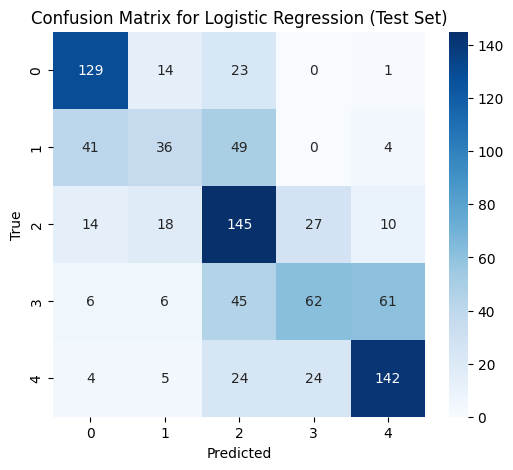


### Decision Tree ###
Validation Accuracy: 0.6978
Test Accuracy: 0.6978

Validation Classification Report:
              precision    recall  f1-score     support
0.0            0.755952  0.760479  0.758209  167.000000
1.0            0.507353  0.534884  0.520755  129.000000
2.0            0.621359  0.595349  0.608076  215.000000
3.0            0.720930  0.688889  0.704545  180.000000
4.0            0.831731  0.869347  0.850123  199.000000
accuracy       0.697753  0.697753  0.697753    0.697753
macro avg      0.687465  0.689789  0.688342  890.000000
weighted avg   0.697266  0.697753  0.697222  890.000000

Test Classification Report:
              precision    recall  f1-score     support
0.0            0.754601  0.736527  0.745455  167.000000
1.0            0.549020  0.646154  0.593640  130.000000
2.0            0.686486  0.593458  0.636591  214.000000
3.0            0.658291  0.727778  0.691293  180.000000
4.0            0.821053  0.783920  0.802057  199.000000
accuracy       0.697753

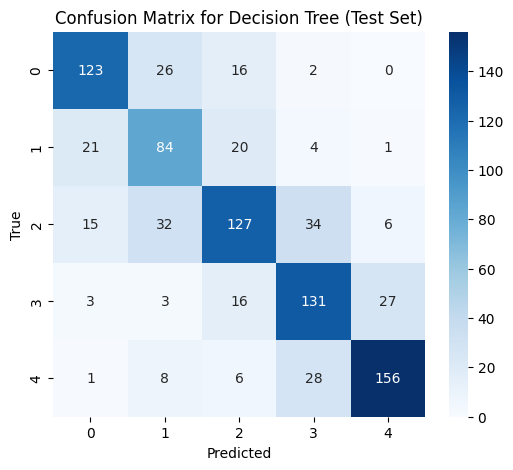


### Random Forest ###
Validation Accuracy: 0.7742
Test Accuracy: 0.7978

Validation Classification Report:
              precision    recall  f1-score     support
0.0            0.832370  0.862275  0.847059  167.000000
1.0            0.600000  0.581395  0.590551  129.000000
2.0            0.717593  0.720930  0.719258  215.000000
3.0            0.783333  0.783333  0.783333  180.000000
4.0            0.887755  0.874372  0.881013  199.000000
accuracy       0.774157  0.774157  0.774157    0.774157
macro avg      0.764210  0.764461  0.764243  890.000000
weighted avg   0.773429  0.774157  0.773710  890.000000

Test Classification Report:
              precision    recall  f1-score     support
0.0            0.880240  0.880240  0.880240  167.000000
1.0            0.666667  0.661538  0.664093  130.000000
2.0            0.740909  0.761682  0.751152  214.000000
3.0            0.787234  0.822222  0.804348  180.000000
4.0            0.892473  0.834171  0.862338  199.000000
accuracy       0.797753

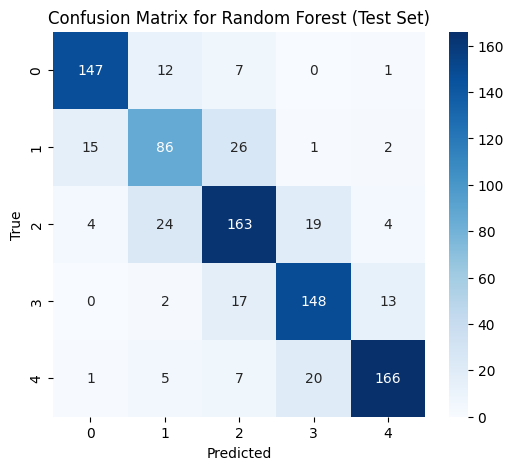


### Gradient Boosting ###
Validation Accuracy: 0.7640
Test Accuracy: 0.7573

Validation Classification Report:
              precision    recall  f1-score     support
0.0            0.834286  0.874251  0.853801  167.000000
1.0            0.614035  0.542636  0.576132  129.000000
2.0            0.692982  0.734884  0.713318  215.000000
3.0            0.775148  0.727778  0.750716  180.000000
4.0            0.857843  0.879397  0.868486  199.000000
accuracy       0.764045  0.764045  0.764045    0.764045
macro avg      0.754859  0.751789  0.752491  890.000000
weighted avg   0.761534  0.764045  0.762053  890.000000

Test Classification Report:
              precision    recall  f1-score     support
0.0            0.834320  0.844311  0.839286  167.000000
1.0            0.641026  0.576923  0.607287  130.000000
2.0            0.663866  0.738318  0.699115  214.000000
3.0            0.759563  0.772222  0.765840  180.000000
4.0            0.879781  0.809045  0.842932  199.000000
accuracy       0.75

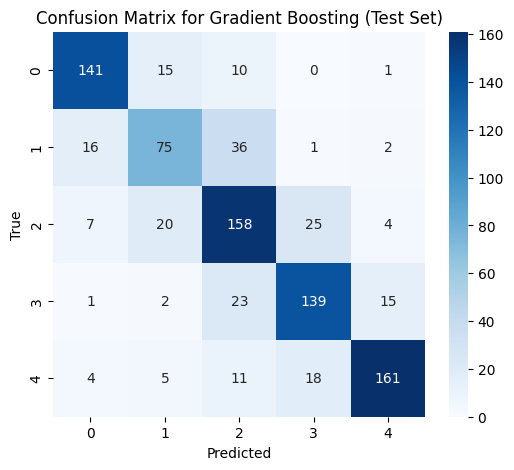


### SVC ###
Validation Accuracy: 0.7225
Test Accuracy: 0.6831

Validation Classification Report:
              precision    recall  f1-score     support
0.0            0.682692  0.850299  0.757333  167.000000
1.0            0.564356  0.441860  0.495652  129.000000
2.0            0.669725  0.679070  0.674365  215.000000
3.0            0.811321  0.716667  0.761062  180.000000
4.0            0.828431  0.849246  0.838710  199.000000
accuracy       0.722472  0.722472  0.722472    0.722472
macro avg      0.711305  0.707429  0.705424  890.000000
weighted avg   0.721009  0.722472  0.718311  890.000000

Test Classification Report:
              precision    recall  f1-score     support
0.0            0.644330  0.748503  0.692521  167.000000
1.0            0.508772  0.446154  0.475410  130.000000
2.0            0.653680  0.705607  0.678652  214.000000
3.0            0.740741  0.666667  0.701754  180.000000
4.0            0.814815  0.773869  0.793814  199.000000
accuracy       0.683146  0.683146

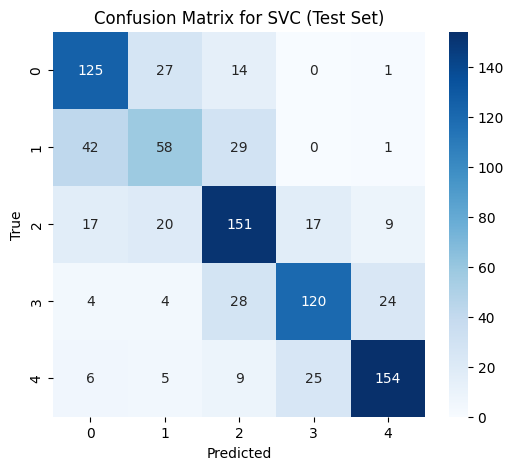


### K-Neighbors ###
Validation Accuracy: 0.6764
Test Accuracy: 0.6292

Validation Classification Report:
              precision    recall  f1-score     support
0.0            0.693878  0.814371  0.749311  167.000000
1.0            0.452555  0.480620  0.466165  129.000000
2.0            0.619048  0.604651  0.611765  215.000000
3.0            0.714286  0.611111  0.658683  180.000000
4.0            0.849741  0.824121  0.836735  199.000000
accuracy       0.676404  0.676404  0.676404    0.676404
macro avg      0.665901  0.666975  0.664532  890.000000
weighted avg   0.679800  0.676404  0.676262  890.000000

Test Classification Report:
              precision    recall  f1-score     support
0.0            0.628415  0.688623  0.657143  167.000000
1.0            0.405405  0.461538  0.431655  130.000000
2.0            0.615023  0.612150  0.613583  214.000000
3.0            0.650888  0.611111  0.630372  180.000000
4.0            0.813559  0.723618  0.765957  199.000000
accuracy       0.629213  

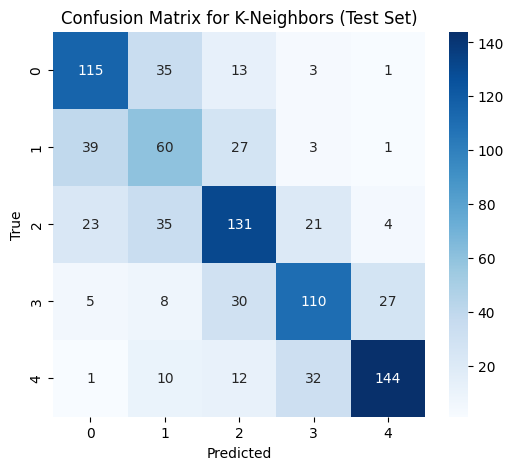

In [16]:
print("\n--- Model Evaluation Results ---")
for name, res in results.items():
    print(f"\n### {name} ###")
    print(f"Validation Accuracy: {res['accuracy_val']:.4f}")
    print(f"Test Accuracy: {res['accuracy_test']:.4f}")

    print("\nValidation Classification Report:")
    print(pd.DataFrame(res['classification_report_val']).transpose())

    print("\nTest Classification Report:")
    print(pd.DataFrame(res['classification_report_test']).transpose())

    print("\nConfusion Matrix (Test Set):")
    plt.figure(figsize=(6, 5))
    sns.heatmap(res['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y_test).astype(int), yticklabels=np.unique(y_test).astype(int))
    plt.title(f'Confusion Matrix for {name} (Test Set)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

In [17]:
# Load the saved model pipeline
loaded_model_pipeline = joblib.load('best_nutriscore_model.pkl')
print("Model loaded successfully!")

# Make predictions on the test set using the loaded model
y_pred_loaded = loaded_model_pipeline.predict(X_test)

# Evaluate the loaded model's predictions (should match the Random Forest results)
loaded_model_accuracy_test = accuracy_score(y_test, y_pred_loaded)
loaded_model_report_test = classification_report(y_test, y_pred_loaded, output_dict=True, zero_division=0)

# Get validation results for the best model from the 'results' dictionary
best_model_name = 'Random Forest' # Assuming Random Forest was identified as best in previous step
loaded_model_accuracy_val = results[best_model_name]['accuracy_val']
loaded_model_report_val = results[best_model_name]['classification_report_val']

print(f"\nValidation Accuracy of loaded model: {loaded_model_accuracy_val:.4f}")
print("\nValidation Classification Report of loaded model:\n")
print(pd.DataFrame(loaded_model_report_val).transpose())

print(f"\nTest Accuracy of loaded model: {loaded_model_accuracy_test:.4f}")
print("\nTest Classification Report of loaded model:\n")
print(pd.DataFrame(loaded_model_report_test).transpose())

# Display some sample predictions
print("\nSample Predictions (True vs. Predicted):")
sample_predictions = pd.DataFrame({'True': y_test.values, 'Predicted': y_pred_loaded})
display(sample_predictions.head())

Model loaded successfully!

Validation Accuracy of loaded model: 0.7742

Validation Classification Report of loaded model:

              precision    recall  f1-score     support
0.0            0.832370  0.862275  0.847059  167.000000
1.0            0.600000  0.581395  0.590551  129.000000
2.0            0.717593  0.720930  0.719258  215.000000
3.0            0.783333  0.783333  0.783333  180.000000
4.0            0.887755  0.874372  0.881013  199.000000
accuracy       0.774157  0.774157  0.774157    0.774157
macro avg      0.764210  0.764461  0.764243  890.000000
weighted avg   0.773429  0.774157  0.773710  890.000000

Test Accuracy of loaded model: 0.7978

Test Classification Report of loaded model:

              precision    recall  f1-score     support
0.0            0.880240  0.880240  0.880240  167.000000
1.0            0.666667  0.661538  0.664093  130.000000
2.0            0.740909  0.761682  0.751152  214.000000
3.0            0.787234  0.822222  0.804348  180.000000
4.0    

,True,Predicted
0,4.0,2.0
1,0.0,1.0
2,2.0,3.0
3,3.0,3.0
4,4.0,4.0


In [18]:
from sklearn.model_selection import GridSearchCV

# Define the best model's pipeline again to ensure consistency
# (or use the already loaded best_model_pipeline if available and it's RandomForest)

# If the loaded_model_pipeline is not Random Forest, re-initialize it for Random Forest
# For simplicity, we'll assume best_model_name was 'Random Forest' from the previous step

best_model_name = 'Random Forest' # Confirming the best model name
rf_model = models[best_model_name]

# Define the pipeline with StandardScaler and RandomForestClassifier
pipeline_rf = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('rf', RandomForestClassifier(random_state=42))
    ]
)

# Define the hyperparameter grid for Random Forest
# Starting with a small grid for demonstration to keep runtime manageable
param_grid_rf = {
    'rf__n_estimators': [100, 200],  # Number of trees in the forest
    'rf__max_depth': [None, 10, 20],   # Maximum depth of the tree
    'rf__min_samples_leaf': [1, 2],    # Minimum number of samples required at each leaf node
    'rf__min_samples_split': [2, 5]    # Minimum number of samples required to split an internal node
}

print("Starting GridSearchCV for Random Forest...")
# Initialize GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    cv=3, # Using 3-fold cross-validation for speed
    scoring='accuracy', # Optimize for accuracy
    n_jobs=-1, # Use all available cores
    verbose=2
)

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train, y_train)

print("GridSearchCV completed.")

# Get the best parameters and best score
best_params_rf = grid_search_rf.best_params_
best_score_rf = grid_search_rf.best_score_

print(f"Best parameters for Random Forest: {best_params_rf}")
print(f"Best cross-validation accuracy for Random Forest: {best_score_rf:.4f}")

# Evaluate the best estimator on the test set
best_rf_model = grid_search_rf.best_estimator_
y_pred_tuned_test = best_rf_model.predict(X_test)
accuracy_tuned_test = accuracy_score(y_test, y_pred_tuned_test)
report_tuned_test = classification_report(
    y_test, y_pred_tuned_test, output_dict=True, zero_division=0
)

print(f"\nTest Accuracy after Hyperparameter Tuning: {accuracy_tuned_test:.4f}")
print("\nTest Classification Report after Hyperparameter Tuning:\n")
print(pd.DataFrame(report_tuned_test).transpose())

Starting GridSearchCV for Random Forest...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
GridSearchCV completed.
Best parameters for Random Forest: {'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}
Best cross-validation accuracy for Random Forest: 0.7735

Test Accuracy after Hyperparameter Tuning: 0.7978

Test Classification Report after Hyperparameter Tuning:

              precision    recall  f1-score     support
0.0            0.880240  0.880240  0.880240  167.000000
1.0            0.666667  0.661538  0.664093  130.000000
2.0            0.740909  0.761682  0.751152  214.000000
3.0            0.787234  0.822222  0.804348  180.000000
4.0            0.892473  0.834171  0.862338  199.000000
accuracy       0.797753  0.797753  0.797753    0.797753
macro avg      0.793504  0.791971  0.792434  890.000000
weighted avg   0.799467  0.797753  0.798277  890.000000


In [19]:
import joblib

# Save the best tuned model
model_filename_tuned = 'tuned_nutriscore_model.pkl'
joblib.dump(best_rf_model, model_filename_tuned)
print(f"Tuned Random Forest model saved as '{model_filename_tuned}'")

Tuned Random Forest model saved as 'tuned_nutriscore_model.pkl'
